# Évaluation de checkpoints fixes (CSI / MSE / L1)
Entrées manuelles : méthodes à comparer, chemins de données (normal/multimesh), checkpoints fixes.
Calculs : CSI (seuil fixé), MSE (h, u, v) et L1/MAE (h, u, v) pour des horizons horaires.
Sorties : courbes (CSI, L1) et CSV long-format pour comparaison inter-méthodes.



In [1]:
import os, json, math
import torch, dgl
import numpy as np
import matplotlib.pyplot as plt
from typing import List
import sys

# Ajouter le repo au PYTHONPATH
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.append(ROOT)

from python.create_dgl_dataset import TelemacDataset, TelemacDatasetWithQ
from python.eval_rollout import (
    build_model as _build_rollout_model,
    build_rollout_context,
    create_rollout_state,
    denormalize_state,
    load_model_checkpoint as _load_rollout_model_checkpoint,
    rollout_step,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [2]:
# =====================
# Paramètres utilisateur (à adapter)
# =====================

# Graphes de base (normal vs multimesh)
DATA_DIRS = {
    "multimesh": "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Multimesh_8_32.bin",
    "normal": '/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Mesh8_base.bin',
}
DEFAULT_MESH = "multimesh"

# PKL de test (par défaut)
DYNAMIC_DIR = [ 
    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_1_peak_2600_Group_1_peak_2600_0_35-64_interpolated.pkl",
    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_2_peak_1000_Group_2_peak_1000_0_35-64_interpolated.pkl",
    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_2_peak_1200_Group_2_peak_1200_0_35-64_interpolated.pkl",
    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_2_peak_1600_Group_2_peak_1600_0_35-64_interpolated.pkl",
    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_4_peak_2000_Group_4_peak_2000_0_35-64_interpolated.pkl",
    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_1_peak_1200_Group_1_peak_1200_0_35-64_interpolated.pkl",
    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_1_peak_2400_Group_1_peak_2400_0_35-64_interpolated.pkl",
    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_3_peak_3400_Group_3_peak_3400_0_35-64_interpolated.pkl",]
    #]+[
#    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_1_peak_1400_Group_1_peak_1400_0_35-64_interpolated.pkl",
#    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_1_peak_2000_Group_1_peak_2000_0_35-64_interpolated.pkl",
#    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_1_peak_2200_Group_1_peak_2200_0_35-64_interpolated.pkl",
#    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_2_peak_3600_Group_2_peak_3600_0_35-64_interpolated.pkl",
#    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_3_peak_2200_Group_3_peak_2200_0_35-64_interpolated.pkl",
#    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_3_peak_2800_Group_3_peak_2800_0_35-64_interpolated.pkl",
#    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_4_peak_1200_Group_4_peak_1200_0_35-64_interpolated.pkl",
#    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_4_peak_3000_Group_4_peak_3000_0_35-64_interpolated.pkl",
#]

#DYNAMIC_DIR = ["/work/m24046/m24046mrcr/results_data_30min/Group_1_peak_2600_Group_1_peak_2600_0_0-80.pkl"]
# Activer Q exogène

#HYDRO_DIR = ['/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_1_peak_2600.liq']
HYDRO_DIR = [
    '/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_1_peak_2600.liq',
    '/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_2_peak_1000.liq',
    '/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_2_peak_1200.liq',
    '/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_2_peak_1600.liq',
    '/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_4_peak_2000.liq',
    '/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_1_peak_1200.liq',
    '/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_1_peak_2400.liq',
    '/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_3_peak_3400.liq',
]#+[
#    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_1_peak_1400.liq",
#    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_1_peak_2000.liq",
#    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_1_peak_2200.liq",
#    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_2_peak_3600.liq",
#    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_3_peak_2200.liq",
#    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_3_peak_2800.liq",
#    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_4_peak_1200.liq",
#    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_4_peak_3000.liq",
#]
DT_SECONDS = 1800.0

# Méthodes à comparer (checkpoint fixe)
# - "epoch" pour un seul checkpoint
# - "epochs" pour en évaluer plusieurs d'un coup
# - "mesh": "normal" ou "multimesh"
METHODS = [

    {
        "name": "Experience7_normalmesh_Q",
        "ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience7/Seed0/",
        "epoch": 900,
        "use_q_feature": True,
        "mesh": "normal",
    },
    {
        "name": "Experience9_normalmesh_Q",
        "ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience9/Seed0/",
        "epoch": 900,
        "use_q_feature": True,
        "mesh": "normal",
    },
        {
        "name": "Experience8_multimesh_Q",
        "ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience8/Seed0/",
        "epoch": 900,
        "use_q_feature": True,
        "mesh": "multimesh",
    },
    {
        "name": "Experience10_multimesh_Q",
        "ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience10/Seed0/",
        "epoch": 900,
        "use_q_feature": True,
        "mesh": "multimesh",
    },
]

METHODS = [
    {
        "name": "Experiment 1",
        "ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience1/Seed0/",
        "epoch": 900,
        "use_q_feature": False,
        "mesh": "normal",
    },
    {
        "name": "Experiment 2",
        "ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience7/Seed0/",
        "epoch": 900,
        "use_q_feature": True,
        "mesh": "normal",
    },
    {
        "name": "Experiment 3",
        "ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience9/Seed0/",
        "epoch": 900,
        "use_q_feature": True,
        "mesh": "normal",
    },
    {
        "name": "Experiment 4",
        "ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience2/Seed0/",
        "epoch": 900,
        "use_q_feature": False,
        "mesh": "multimesh",
    },
    {
        "name": "Experiment 5",
        "ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience8/Seed0/",
        "epoch": 900,
        "use_q_feature": True,
        "mesh": "multimesh",
    },
    {
        "name": "Experiment 6",
        "ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience10/Seed0/",
        "epoch": 900,
        "use_q_feature": True,
        "mesh": "multimesh",
    },
]


# Paramètres modèle (cohérents avec l'entraînement)
NUM_EDGE_FEATURES = 3
NUM_OUTPUT_FEATURES = 3
MP_LAYERS = 10
DO_CONCAT_TRICK = True
NUM_PROCESSOR_CHECKPOINT_SEGMENTS = 0

# Horizons : CSI toutes les heures (pas de 30 min)
REQUESTED_MAX_HOURS = 40
HOUR_IN_STEPS = max(1, int(round(3600.0 / DT_SECONDS)))

# Nombre de séquences à évaluer (prend les premières)
MAX_SEQUENCES = 205

# Seuil CSI
THRESHOLD_M = 0.1

# Export CSV
OUTPUT_CSV_PATH = "/work/m24046/m24046mrcr/paper/eval_fixed_checkpoints_hourly.csv"



In [3]:
import pickle as pkl

def get_dynamic_length(file_path):
    with open(file_path, 'rb') as f:
        return len(pkl.load(f))

dynamic_lengths = [get_dynamic_length(path) for path in DYNAMIC_DIR]
min_num_samples = min(dynamic_lengths)
max_available_step = max(1, min_num_samples - 1)
available_max_hours = max_available_step // HOUR_IN_STEPS

if available_max_hours < 1:
    raise ValueError(
        "Aucun horizon horaire disponible avec les fichiers DYNAMIC_DIR courants."
    )

if available_max_hours < REQUESTED_MAX_HOURS:
    print(
        f"Attention: au moins un fichier test ne contient que {min_num_samples} echantillons. "
        f"Le notebook evaluera donc {available_max_hours} heures au lieu de {REQUESTED_MAX_HOURS}."
    )

MAX_HOURS = available_max_hours
HORIZONS_STEPS = [h * HOUR_IN_STEPS for h in range(1, MAX_HOURS + 1)]
print(
    f"min_num_samples={min_num_samples} | MAX_HOURS={MAX_HOURS} | "
    f"max_horizon_step={HORIZONS_STEPS[-1]}"
)

Attention: au moins un fichier test ne contient que 30 echantillons. Le notebook evaluera donc 14 heures au lieu de 40.
min_num_samples=30 | MAX_HOURS=14 | max_horizon_step=28


In [9]:
# =====================
# Fonctions utilitaires
# =====================
def build_model(num_input_features):
    return _build_rollout_model(
        num_input_features=num_input_features,
        num_edge_features=NUM_EDGE_FEATURES,
        num_output_features=NUM_OUTPUT_FEATURES,
        mp_layers=MP_LAYERS,
        do_concat_trick=DO_CONCAT_TRICK,
        num_processor_checkpoint_segments=NUM_PROCESSOR_CHECKPOINT_SEGMENTS,
    )

def load_model_checkpoint(model, ckpt_dir, epoch):
    return _load_rollout_model_checkpoint(model, ckpt_dir, epoch, device=device)

def build_dataset(
    sequence_length,
    ckpt_dir,
    use_q_feature,
    data_dir,
    overlap=1,
    split="test",
    dynamic_dir=None,
    hydro_dir=None,
):
    dynamic_files = dynamic_dir if dynamic_dir is not None else DYNAMIC_DIR
    hydro_files = hydro_dir if hydro_dir is not None else HYDRO_DIR

    if use_q_feature:
        if len(hydro_files) == 0:
            raise ValueError("use_q_feature=True mais hydro_dir est vide.")
        if len(hydro_files) != len(dynamic_files):
            raise ValueError(
                f"hydro_dir ({len(hydro_files)}) et dynamic_dir ({len(dynamic_files)}) doivent avoir la même longueur."
            )
        ds = TelemacDatasetWithQ(
            name=f"eval_{split}",
            data_dir=data_dir,
            dynamic_data_files=dynamic_files,
            hydro_data_files=hydro_files,
            split=split,
            ckpt_path=ckpt_dir,
            normalize=True,
            sequence_length=sequence_length,
            overlap=overlap,
            dt_seconds=DT_SECONDS,
        )
    else:
        ds = TelemacDataset(
            name=f"eval_{split}",
            data_dir=data_dir,
            dynamic_data_files=dynamic_files,
            split=split,
            ckpt_path=ckpt_dir,
            normalize=True,
            sequence_length=sequence_length,
            overlap=overlap,
        )
    return ds

def csi_from_binary(pred_mask, gt_mask):
    tp = np.logical_and(pred_mask, gt_mask).sum()
    fp = np.logical_and(pred_mask, ~gt_mask).sum()
    fn = np.logical_and(~pred_mask, gt_mask).sum()
    denom = tp + fp + fn
    return float(tp / denom) if denom > 0 else math.nan

def evaluate_model(model, ds, horizons_steps, use_q_feature, max_sequences=10, threshold=0.3):
    rollout_context = build_rollout_context(ds, device=device, use_q_feature=use_q_feature)
    agg = {h: {"mse": [], "l1": [], "csi": []} for h in horizons_steps}
    step_set = set(horizons_steps)
    nseq = min(max_sequences, len(ds))
    max_h = max(horizons_steps)

    for idx in range(nseq):
        graphs = ds[idx]
        if len(graphs) <= max_h:
            continue

        rollout_state = create_rollout_state(graphs[0], rollout_context)

        for t in range(max_h):
            x_gt_full_n = graphs[t + 1].ndata["x"][
                :, rollout_context.dyn_start:rollout_context.dyn_start + rollout_context.dyn_len
            ].to(device)
            x_gt = denormalize_state(x_gt_full_n[:, :3], rollout_context)
            q_t1_n = x_gt_full_n[:, 3:4] if use_q_feature else None

            step_result = rollout_step(
                model,
                rollout_state,
                rollout_context,
                x_gt=x_gt,
                q_t1_n=q_t1_n,
            )

            step = t + 1
            if step in step_set:
                mse = torch.mean(
                    (step_result.predicted_state - step_result.target_state) ** 2,
                    dim=0,
                ).detach().cpu().numpy()
                l1 = torch.mean(
                    torch.abs(step_result.predicted_state - step_result.target_state),
                    dim=0,
                ).detach().cpu().numpy()
                h_pred = step_result.predicted_state[:, 0].detach().cpu().numpy()
                h_gt = step_result.target_state[:, 0].detach().cpu().numpy()
                csi = csi_from_binary(h_pred >= threshold, h_gt >= threshold)
                agg[step]["mse"].append(mse)
                agg[step]["l1"].append(l1)
                agg[step]["csi"].append(csi)

            rollout_state = step_result.next_state

    summary = {}
    for h in horizons_steps:
        if len(agg[h]["mse"]) == 0:
            continue
        summary[h] = {
            "mse_mean": np.nanmean(np.stack(agg[h]["mse"], axis=0), axis=0).tolist(),
            "l1_mean": np.nanmean(np.stack(agg[h]["l1"], axis=0), axis=0).tolist(),
            "csi_mean": float(np.nanmean(agg[h]["csi"])),
        }
    return summary

def evaluate_single_checkpoint(
    ckpt_dir,
    epoch,
    horizons_steps,
    max_sequences=10,
    threshold=0.05,
    use_q_feature=None,
    data_dir=None,
    dynamic_dir=None,
    hydro_dir=None,
):
    if use_q_feature is None:
        raise ValueError("use_q_feature doit être fourni explicitement.")
    resolved_data_dir = data_dir if data_dir is not None else DATA_DIRS.get(DEFAULT_MESH)
    if not resolved_data_dir:
        raise ValueError(
            f"Aucun data_dir résolu pour DEFAULT_MESH={DEFAULT_MESH}. "
            "Renseigne DATA_DIRS ou method['data_dir']."
        )

    ds = build_dataset(
        sequence_length=max(horizons_steps)+1,
        overlap=1,
        split="test",
        ckpt_dir=ckpt_dir,
        use_q_feature=use_q_feature,
        data_dir=resolved_data_dir,
        dynamic_dir=dynamic_dir,
        hydro_dir=hydro_dir,
    )

    if len(ds) == 0:
        raise ValueError(
            f"Aucune sequence disponible pour sequence_length={max(horizons_steps)+1}. "
            "Reduis REQUESTED_MAX_HOURS ou utilise des fichiers dynamiques plus longs."
        )

    expected_input_features = ds.base_graph.ndata['static'].shape[1] + (4 if use_q_feature else 3)
    model = build_model(expected_input_features)
    load_model_checkpoint(model, ckpt_dir, epoch=epoch)

    return evaluate_model(
        model,
        ds,
        horizons_steps,
        use_q_feature=use_q_feature,
        max_sequences=max_sequences,
        threshold=threshold,
    )

def evaluate_fixed_methods(methods, horizons_steps, max_sequences=10, threshold=0.05):
    fixed_metrics = {}
    for method in methods:
        name = method["name"]
        ckpt_dir = method["ckpt_dir"]
        use_q_feature = method["use_q_feature"]
        dynamic_dir = method.get("dynamic_dir", DYNAMIC_DIR)
        hydro_dir = method.get("hydro_dir", HYDRO_DIR)
        mesh = method.get("mesh", DEFAULT_MESH)

        if "data_dir" in method:
            data_dir = method["data_dir"]
        else:
            if mesh not in DATA_DIRS:
                raise ValueError(
                    f"Méthode {name}: mesh='{mesh}' inconnu. Choix possibles: {list(DATA_DIRS.keys())}."
                )
            data_dir = DATA_DIRS[mesh]

        if not data_dir:
            raise ValueError(
                f"Méthode {name}: data_dir vide pour mesh='{mesh}'. "
                "Renseigne DATA_DIRS[mesh] ou method['data_dir']."
            )

        if "epochs" in method:
            epochs = list(method["epochs"])
        elif "epoch" in method:
            epochs = [method["epoch"]]
        else:
            raise ValueError(f"Méthode {name}: il faut fournir 'epoch' ou 'epochs'.")

        for epoch in epochs:
            run_name = f"{name}@{epoch}"
            summary = evaluate_single_checkpoint(
                ckpt_dir=ckpt_dir,
                epoch=epoch,
                horizons_steps=horizons_steps,
                max_sequences=max_sequences,
                threshold=threshold,
                use_q_feature=use_q_feature,
                data_dir=data_dir,
                dynamic_dir=dynamic_dir,
                hydro_dir=hydro_dir,
            )
            fixed_metrics[run_name] = {
                "method": name,
                "mesh": mesh,
                "data_dir": data_dir,
                "epoch": epoch,
                "ckpt_dir": ckpt_dir,
                "threshold_m": threshold,
                "summary": summary,
            }
    return fixed_metrics

def plot_hourly_csi(fixed_metrics, horizons_steps):
    if not fixed_metrics:
        print("Pas de résultats")
        return

    hours = [step * DT_SECONDS / 3600.0 for step in horizons_steps]
    plt.figure(figsize=(12, 4))

    for run_name, payload in fixed_metrics.items():
        summary = payload["summary"]
        csi_vals = [summary.get(step, {}).get("csi_mean", np.nan) for step in horizons_steps]
        plt.plot(hours, csi_vals, marker='o', label=run_name)

    plt.title(f"CSI vs horizon (threshold={THRESHOLD_M:.3f} m)")
    plt.xlabel("Horizon (hours)")
    plt.ylabel("CSI")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_hourly_l1_h(fixed_metrics, horizons_steps):
    if not fixed_metrics:
        print("Pas de résultats")
        return

    hours = [step * DT_SECONDS / 3600.0 for step in horizons_steps]
    plt.figure(figsize=(12, 4))

    for run_name, payload in fixed_metrics.items():
        summary = payload["summary"]
        l1_h_vals = [summary.get(step, {}).get("l1_mean", [np.nan, np.nan, np.nan])[0] for step in horizons_steps]
        plt.plot(hours, l1_h_vals, marker='o', label=run_name)

    plt.title("L1 h vs horizon")
    plt.xlabel("Horizon (hours)")
    plt.ylabel("L1 h")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_hourly_l1_uv_log(fixed_metrics, horizons_steps):
    if not fixed_metrics:
        print("Pas de résultats")
        return

    hours = [step * DT_SECONDS / 3600.0 for step in horizons_steps]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
    components = [(1, "u"), (2, "v")]

    for ax, (comp_idx, comp_name) in zip(axes, components):
        for run_name, payload in fixed_metrics.items():
            summary = payload["summary"]
            vals = np.array([
                summary.get(step, {}).get("l1_mean", [np.nan, np.nan, np.nan])[comp_idx]
                for step in horizons_steps
            ], dtype=float)
            vals[vals <= 0.0] = np.nan
            ax.plot(hours, vals, marker='o', label=run_name)

        ax.set_title(f"L1 {comp_name} vs horizon (log)")
        ax.set_xlabel("Horizon (hours)")
        ax.set_ylabel(f"L1 {comp_name}")
        ax.set_yscale("log")
        ax.grid(True, alpha=0.3)

    #handles, labels = axes[-1].get_legend_handles_labels()
    #if handles:
    #    fig.legend(handles, labels, ncol=2)
    fig.tight_layout()
    plt.show()






In [10]:
# =====================
# Lancement de l'éval (checkpoints fixes)
# =====================
fixed_metrics = evaluate_fixed_methods(
    METHODS,
    horizons_steps=HORIZONS_STEPS,
    max_sequences=MAX_SEQUENCES,
    threshold=THRESHOLD_M,
)
fixed_metrics



Loading normalization statistics...


[10:25:27 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience1/Seed0/MeshGraphNet.0.900.mdlus to device cuda
[10:25:27 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience1/Seed0/checkpoint.0.900.pt to device cuda


Loading normalization statistics...


[10:25:34 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience7/Seed0/MeshGraphNet.0.900.mdlus to device cuda
[10:25:34 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience7/Seed0/checkpoint.0.900.pt to device cuda


Loading normalization statistics...


...

Loading normalization statistics...


[10:25:45 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience8/Seed0/MeshGraphNet.0.900.mdlus to device cuda
[10:25:45 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience8/Seed0/checkpoint.0.900.pt to device cuda


Loading normalization statistics...


[10:25:49 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience10/Seed0/MeshGraphNet.0.900.mdlus to device cuda
[10:25:49 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience10/Seed0/checkpoint.0.900.pt to device cuda


{'Experiment 1@900': {'method': 'Experiment 1',
  'mesh': 'normal',
  'data_dir': '/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Mesh8_base.bin',
  'epoch': 900,
  'ckpt_dir': '/work/m24046/m24046mrcr/paper/Experience1/Seed0/',
  'threshold_m': 0.1,
  'summary': {2: {'mse_mean': [0.004193703643977642,
     0.0014915517531335354,
     0.0005389120779000223],
    'l1_mean': [0.017822347581386566,
     0.010186007246375084,
     0.005981152411550283],
    'csi_mean': 0.9470041660012705},
   4: {'mse_mean': [0.024137847125530243,
     0.007500116713345051,
     0.0022574840113520622],
    'l1_mean': [0.0479995459318161,
     0.025340842083096504,
     0.013402383774518967],
    'csi_mean': 0.8869719972537765},
   6: {'mse_mean': [0.08498270809650421,
     0.023012854158878326,
     0.005636467132717371],
    'l1_mean': [0.0975484549999237, 0.048414893448352814, 0.02330956608057022],
    'csi_mean': 0.8119733894594363},
   8: {'mse_mean': [0.200580894947052,
     0.05073945224285126,
 

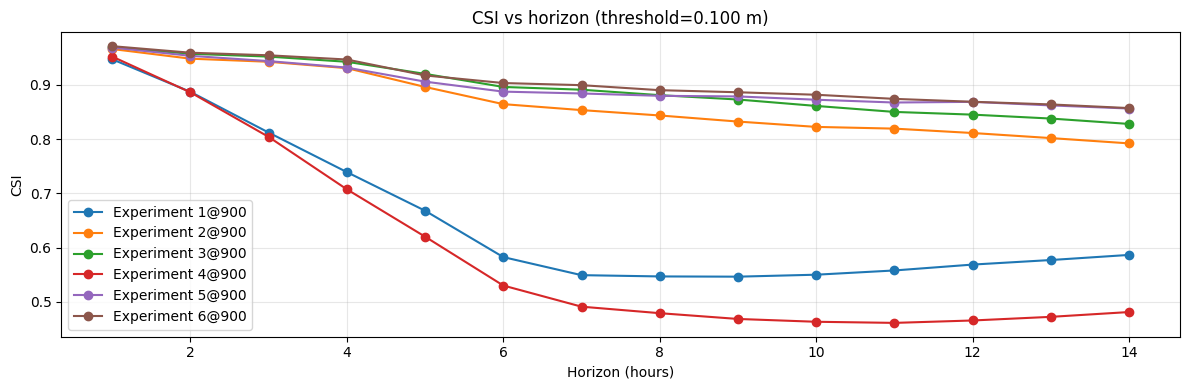

In [11]:
plot_hourly_csi(fixed_metrics, HORIZONS_STEPS)



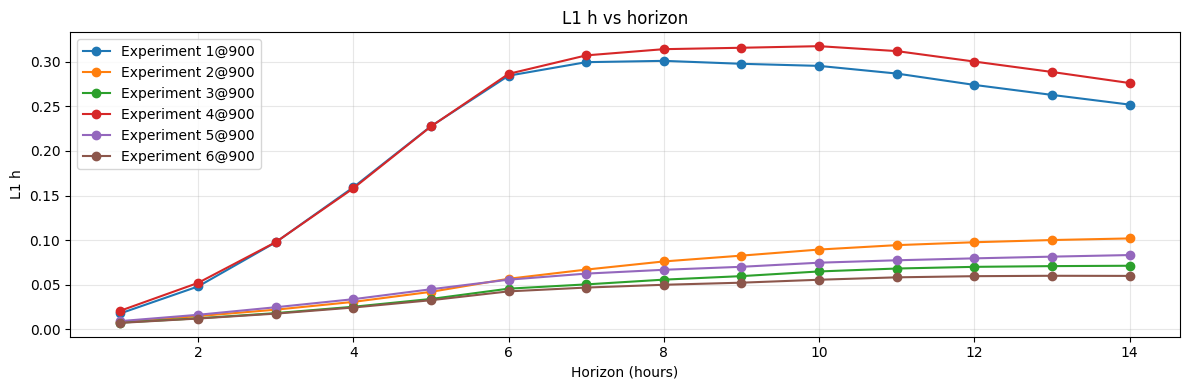

In [12]:
plot_hourly_l1_h(fixed_metrics, HORIZONS_STEPS)


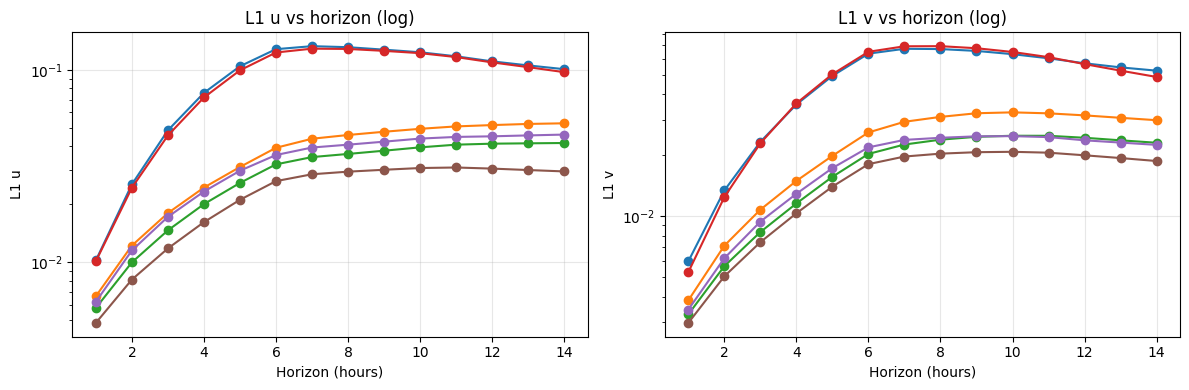

In [13]:
plot_hourly_l1_uv_log(fixed_metrics, HORIZONS_STEPS)



In [14]:
import pandas as pd

rows = []
for run_name, payload in fixed_metrics.items():
    method = payload["method"]
    mesh = payload.get("mesh", "")
    data_dir = payload.get("data_dir", "")
    epoch = payload["epoch"]
    threshold = payload["threshold_m"]
    for h_step, vals in payload["summary"].items():
        mse_mean = vals.get("mse_mean", [np.nan, np.nan, np.nan])
        l1_mean = vals.get("l1_mean", [np.nan, np.nan, np.nan])
        rows.append({
            "run_name": run_name,
            "method": method,
            "mesh": mesh,
            "data_dir": data_dir,
            "epoch": epoch,
            "horizon_steps": h_step,
            "horizon_hours": h_step * DT_SECONDS / 3600.0,
            "threshold_m": threshold,
            "mse_h": mse_mean[0],
            "mse_u": mse_mean[1],
            "mse_v": mse_mean[2],
            "l1_h": l1_mean[0],
            "l1_u": l1_mean[1],
            "l1_v": l1_mean[2],
            "csi": vals.get("csi_mean", np.nan),
        })

df = pd.DataFrame(rows).sort_values(["method", "epoch", "horizon_steps"]).reset_index(drop=True)

if OUTPUT_CSV_PATH:
    os.makedirs(os.path.dirname(OUTPUT_CSV_PATH), exist_ok=True)
    df.to_csv(OUTPUT_CSV_PATH, index=False)
    print(f"CSV sauvegardé: {OUTPUT_CSV_PATH}")

df





CSV sauvegardé: /work/m24046/m24046mrcr/paper/eval_fixed_checkpoints_hourly.csv


,run_name,method,mesh,data_dir,epoch,horizon_steps,horizon_hours,threshold_m,mse_h,mse_u,mse_v,l1_h,l1_u,l1_v,csi
0,Experiment 1@900,Experiment 1,normal,/work/m24046/m24046mrcr/dataset_x8_avec_ts/sho...,900,2,1.0,0.1,0.004194,0.001492,0.000539,0.017822,0.010186,0.005981,0.947004
1,Experiment 1@900,Experiment 1,normal,/work/m24046/m24046mrcr/dataset_x8_avec_ts/sho...,900,4,2.0,0.1,0.024138,0.007500,0.002257,0.048000,0.025341,0.013402,0.886972
2,Experiment 1@900,Experiment 1,normal,/work/m24046/m24046mrcr/dataset_x8_avec_ts/sho...,900,6,3.0,0.1,0.084983,0.023013,0.005636,0.097548,0.048415,0.023310,0.811973
3,Experiment 1@900,Experiment 1,normal,/work/m24046/m24046mrcr/dataset_x8_avec_ts/sho...,900,8,4.0,0.1,0.200581,0.050739,0.011259,0.159266,0.075829,0.035664,0.739119
4,Experiment 1@900,Experiment 1,normal,/work/m24046/m24046mrcr/dataset_x8_avec_ts/sho...,900,10,5.0,0.1,0.384209,0.088911,0.018739,0.227736,0.104337,0.049415,0.667960
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,Experiment 6@900,Experiment 6,multimesh,/work/m24046/m24046mrcr/dataset_x8_avec_ts/sho...,900,20,10.0,0.1,0.013696,0.005495,0.002481,0.055524,0.030814,0.020803,0.881573
80,Experiment 6@900,Experiment 6,multimesh,/work/m24046/m24046mrcr/dataset_x8_avec_ts/sho...,900,22,11.0,0.1,0.015463,0.005769,0.002416,0.058220,0.031013,0.020596,0.874006
81,Experiment 6@900,Experiment 6,multimesh,/work/m24046/m24046mrcr/dataset_x8_avec_ts/sho...,900,24,12.0,0.1,0.016432,0.005832,0.002322,0.059517,0.030606,0.019993,0.868698
82,Experiment 6@900,Experiment 6,multimesh,/work/m24046/m24046mrcr/dataset_x8_avec_ts/sho...,900,26,13.0,0.1,0.016894,0.005823,0.002245,0.059973,0.030086,0.019375,0.863750


Loading normalization statistics...


[10:25:54 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience1/Seed0/MeshGraphNet.0.900.mdlus to device cuda
[10:25:54 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience1/Seed0/checkpoint.0.900.pt to device cuda
[10:25:58 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience7/Seed0/MeshGraphNet.0.900.mdlus to device cuda


Loading normalization statistics...


[10:25:58 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience7/Seed0/checkpoint.0.900.pt to device cuda
[10:26:01 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience9/Seed0/MeshGraphNet.0.900.mdlus to device cuda


Loading normalization statistics...


...

[10:26:05 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience2/Seed0/checkpoint.0.900.pt to device cuda


Loading normalization statistics...


[10:26:09 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience8/Seed0/MeshGraphNet.0.900.mdlus to device cuda
[10:26:09 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience8/Seed0/checkpoint.0.900.pt to device cuda
[10:26:13 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience10/Seed0/MeshGraphNet.0.900.mdlus to device cuda


Loading normalization statistics...


[10:26:13 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience10/Seed0/checkpoint.0.900.pt to device cuda


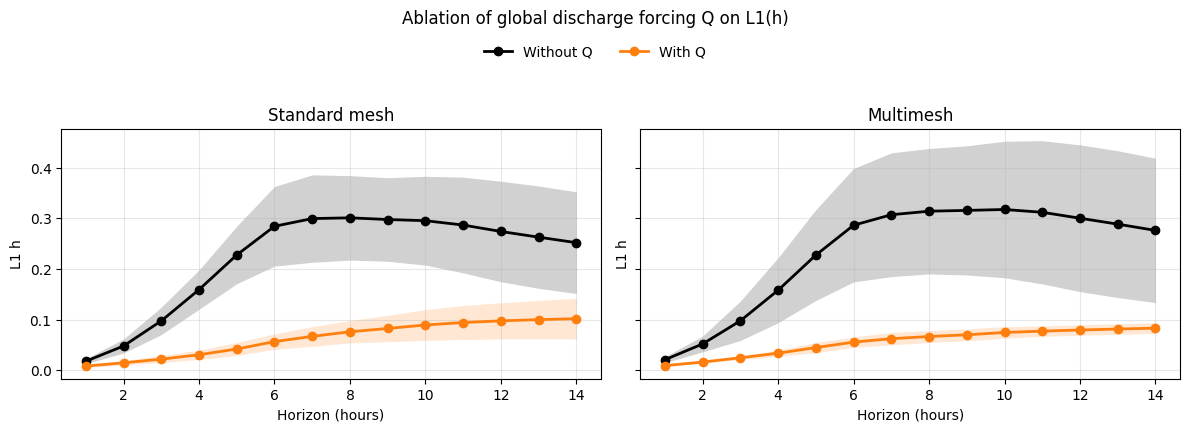

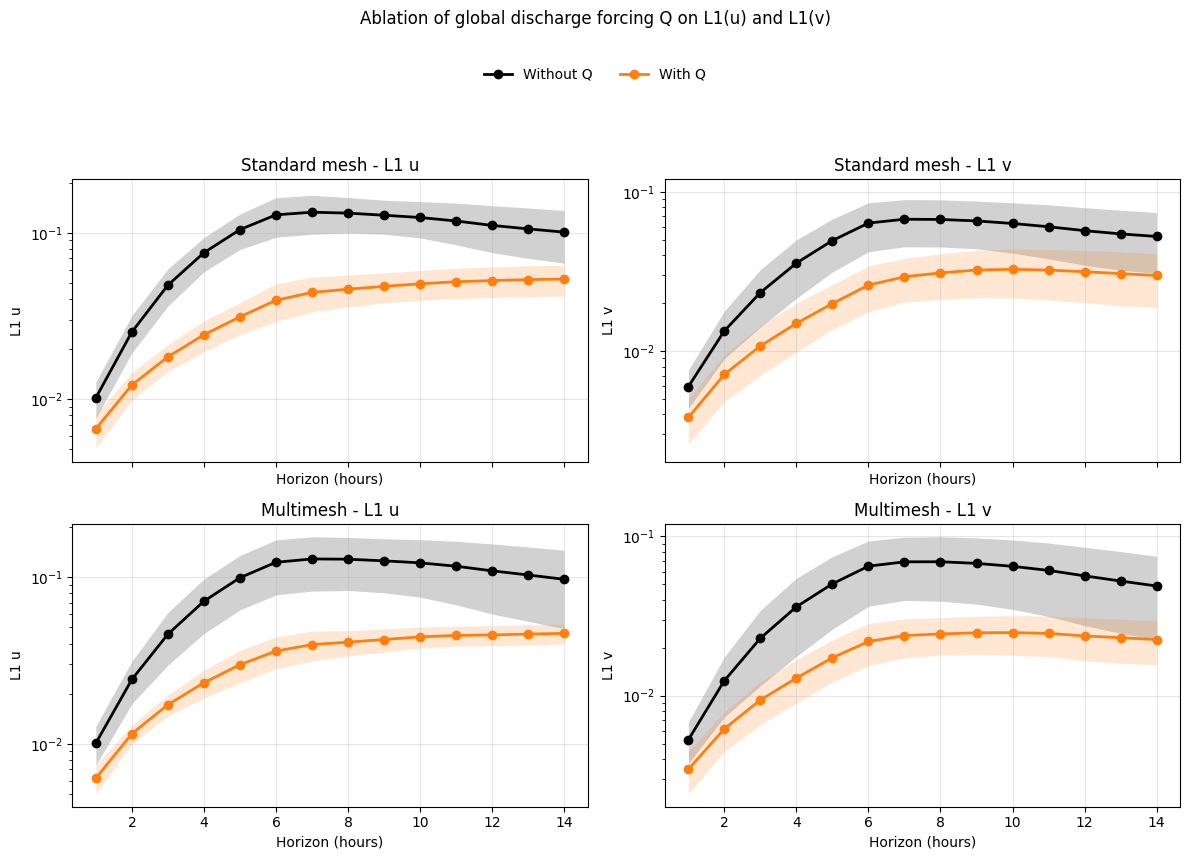

In [15]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# 1) Redefinition de evaluate_model pour stocker mean + std
# ------------------------------------------------------------------
def evaluate_model(model, ds, horizons_steps, use_q_feature, max_sequences=10, threshold=0.05):
    rollout_context = build_rollout_context(ds, device=device, use_q_feature=use_q_feature)
    agg = {h: {"mse": [], "l1": [], "csi": []} for h in horizons_steps}
    step_set = set(horizons_steps)
    nseq = min(max_sequences, len(ds))
    max_h = max(horizons_steps)

    for idx in range(nseq):
        graphs = ds[idx]
        if len(graphs) <= max_h:
            continue

        rollout_state = create_rollout_state(graphs[0], rollout_context)

        for t in range(max_h):
            x_gt_full_n = graphs[t + 1].ndata["x"][
                :, rollout_context.dyn_start:rollout_context.dyn_start + rollout_context.dyn_len
            ].to(device)
            x_gt = denormalize_state(x_gt_full_n[:, :3], rollout_context)
            q_t1_n = x_gt_full_n[:, 3:4] if use_q_feature else None

            step_result = rollout_step(
                model,
                rollout_state,
                rollout_context,
                x_gt=x_gt,
                q_t1_n=q_t1_n,
            )

            step = t + 1
            if step in step_set:
                mse = torch.mean(
                    (step_result.predicted_state - step_result.target_state) ** 2,
                    dim=0,
                ).detach().cpu().numpy()
                l1 = torch.mean(
                    torch.abs(step_result.predicted_state - step_result.target_state),
                    dim=0,
                ).detach().cpu().numpy()
                h_pred = step_result.predicted_state[:, 0].detach().cpu().numpy()
                h_gt = step_result.target_state[:, 0].detach().cpu().numpy()
                csi = csi_from_binary(h_pred >= threshold, h_gt >= threshold)

                agg[step]["mse"].append(mse)
                agg[step]["l1"].append(l1)
                agg[step]["csi"].append(csi)

            rollout_state = step_result.next_state

    summary = {}
    for h in horizons_steps:
        if len(agg[h]["mse"]) == 0:
            continue

        mse_stack = np.stack(agg[h]["mse"], axis=0)
        l1_stack = np.stack(agg[h]["l1"], axis=0)
        csi_vals = np.asarray(agg[h]["csi"], dtype=float)

        summary[h] = {
            "mse_mean": np.nanmean(mse_stack, axis=0).tolist(),
            "mse_std": np.nanstd(mse_stack, axis=0).tolist(),
            "l1_mean": np.nanmean(l1_stack, axis=0).tolist(),
            "l1_std": np.nanstd(l1_stack, axis=0).tolist(),
            "csi_mean": float(np.nanmean(csi_vals)),
            "csi_std": float(np.nanstd(csi_vals)),
        }
    return summary


# ------------------------------------------------------------------
# 2) Helpers robustes pour couleurs + bandes std
# ------------------------------------------------------------------
def _normalize_label(label):
    return (
        label.lower()
        .replace(" ", "")
        .replace("_", "")
        .replace("-", "")
    )

def _style_for_label(label):
    key = _normalize_label(label)

    if "sansq" in key or "noq" in key:
        return dict(color="C0", marker="o", linewidth=2)
    if "avecq" in key or "withq" in key:
        return dict(color="C1", marker="o", linewidth=2)
    if "sanspf" in key or "nopf" in key:
        return dict(color="C2", marker="o", linewidth=2)
    if "avecpf" in key or "withpf" in key:
        return dict(color="C3", marker="o", linewidth=2)

    # fallback visible
    return dict(color="black", marker="o", linewidth=2)

def _build_legend_handles(labels):
    return [Line2D([0], [0], label=label, **_style_for_label(label)) for label in labels]

def _extract_metric_mean_std(fixed_metrics, run_name, horizons_steps, metric_name, comp_idx=None, positive_only=False):
    if run_name not in fixed_metrics:
        available = ", ".join(sorted(fixed_metrics.keys()))
        raise KeyError(f"Run '{run_name}' absent de fixed_metrics. Disponibles: {available}")

    summary = fixed_metrics[run_name]["summary"]

    if comp_idx is None:
        mean_vals = np.array([summary.get(step, {}).get(f"{metric_name}_mean", np.nan) for step in horizons_steps], dtype=float)
        std_vals  = np.array([summary.get(step, {}).get(f"{metric_name}_std",  np.nan) for step in horizons_steps], dtype=float)
    else:
        mean_vals = np.array([
            summary.get(step, {}).get(f"{metric_name}_mean", [np.nan, np.nan, np.nan])[comp_idx]
            for step in horizons_steps
        ], dtype=float)
        std_vals = np.array([
            summary.get(step, {}).get(f"{metric_name}_std", [np.nan, np.nan, np.nan])[comp_idx]
            for step in horizons_steps
        ], dtype=float)

    if positive_only:
        mask = mean_vals <= 0.0
        mean_vals[mask] = np.nan
        std_vals[mask] = np.nan

    return mean_vals, std_vals


# ------------------------------------------------------------------
# 3) Plots Q ablation avec mean ± std
# ------------------------------------------------------------------
def plot_q_ablation_l1_h_std(fixed_metrics, horizons_steps, run_groups, dt_seconds):
    if not fixed_metrics:
        print("Pas de résultats")
        return

    panel_items = list(run_groups.items())
    hours = np.array([step * dt_seconds / 3600.0 for step in horizons_steps], dtype=float)

    fig, axes = plt.subplots(1, len(panel_items), figsize=(6 * len(panel_items), 4.5), sharex=True, sharey=True)
    if len(panel_items) == 1:
        axes = [axes]

    legend_labels = []

    for ax, (panel_title, panel_runs) in zip(axes, panel_items):
        for label, run_name in panel_runs.items():
            mean_vals, std_vals = _extract_metric_mean_std(
                fixed_metrics, run_name, horizons_steps, metric_name="l1", comp_idx=0
            )
            style = _style_for_label(label)
            ax.plot(hours, mean_vals, label=label, **style)
            ax.fill_between(
                hours,
                mean_vals - std_vals,
                mean_vals + std_vals,
                color=style["color"],
                alpha=0.18,
                linewidth=0,
            )
            if label not in legend_labels:
                legend_labels.append(label)

        ax.set_title(panel_title)
        ax.set_xlabel("Horizon (hours)")
        ax.set_ylabel("L1 h")
        ax.grid(True, alpha=0.3)

    fig.suptitle("Ablation of global discharge forcing Q on L1(h)", y=0.95)
    fig.legend(
        handles=_build_legend_handles(legend_labels),
        loc="upper center",
        bbox_to_anchor=(0.5, 0.90),
        ncol=len(legend_labels),
        frameon=False,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.84])
    plt.show()


def plot_q_ablation_l1_uv_log_std(fixed_metrics, horizons_steps, run_groups, dt_seconds):
    if not fixed_metrics:
        print("Pas de résultats")
        return

    panel_items = list(run_groups.items())
    hours = np.array([step * dt_seconds / 3600.0 for step in horizons_steps], dtype=float)
    components = [(1, "u"), (2, "v")]

    fig, axes = plt.subplots(
        len(panel_items), 2,
        figsize=(12, 4.5 * len(panel_items)),
        sharex=True,
        sharey="col",
    )

    if len(panel_items) == 1:
        axes = np.array([axes])

    legend_labels = []

    for row, (panel_title, panel_runs) in enumerate(panel_items):
        for col, (comp_idx, comp_name) in enumerate(components):
            ax = axes[row, col]

            for label, run_name in panel_runs.items():
                mean_vals, std_vals = _extract_metric_mean_std(
                    fixed_metrics,
                    run_name,
                    horizons_steps,
                    metric_name="l1",
                    comp_idx=comp_idx,
                    positive_only=True,
                )
                style = _style_for_label(label)
                ax.plot(hours, mean_vals, label=label, **style)

                lower = mean_vals - std_vals
                upper = mean_vals + std_vals
                lower[lower <= 0.0] = np.nan

                ax.fill_between(
                    hours,
                    lower,
                    upper,
                    color=style["color"],
                    alpha=0.18,
                    linewidth=0,
                )

                if label not in legend_labels:
                    legend_labels.append(label)

            ax.set_title(f"{panel_title} - L1 {comp_name}")
            ax.set_xlabel("Horizon (hours)")
            ax.set_ylabel(f"L1 {comp_name}")
            ax.set_yscale("log")
            ax.grid(True, alpha=0.3)

    fig.suptitle("Ablation of global discharge forcing Q on L1(u) and L1(v)", y=0.95)
    fig.legend(
        handles=_build_legend_handles(legend_labels),
        loc="upper center",
        bbox_to_anchor=(0.5, 0.90),
        ncol=len(legend_labels),
        frameon=False,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.84])
    plt.show()


# ------------------------------------------------------------------
# 4) Groupes pour l'ablation Q
# ------------------------------------------------------------------
Q_ABLATION_RUNS = {
    "Standard mesh": {
        "Without Q": "Experiment 1@900",
        "With Q": "Experiment 2@900",
    },
    "Multimesh": {
        "Without Q": "Experiment 4@900",
        "With Q": "Experiment 5@900",
    },
}


# ------------------------------------------------------------------
# 5) Regeneration des métriques puis plots
# ------------------------------------------------------------------
fixed_metrics = evaluate_fixed_methods(
    METHODS,
    horizons_steps=HORIZONS_STEPS,
    max_sequences=MAX_SEQUENCES,
    threshold=THRESHOLD_M,
)

plot_q_ablation_l1_h_std(
    fixed_metrics,
    HORIZONS_STEPS,
    run_groups=Q_ABLATION_RUNS,
    dt_seconds=DT_SECONDS,
)

plot_q_ablation_l1_uv_log_std(
    fixed_metrics,
    HORIZONS_STEPS,
    run_groups=Q_ABLATION_RUNS,
    dt_seconds=DT_SECONDS,
)




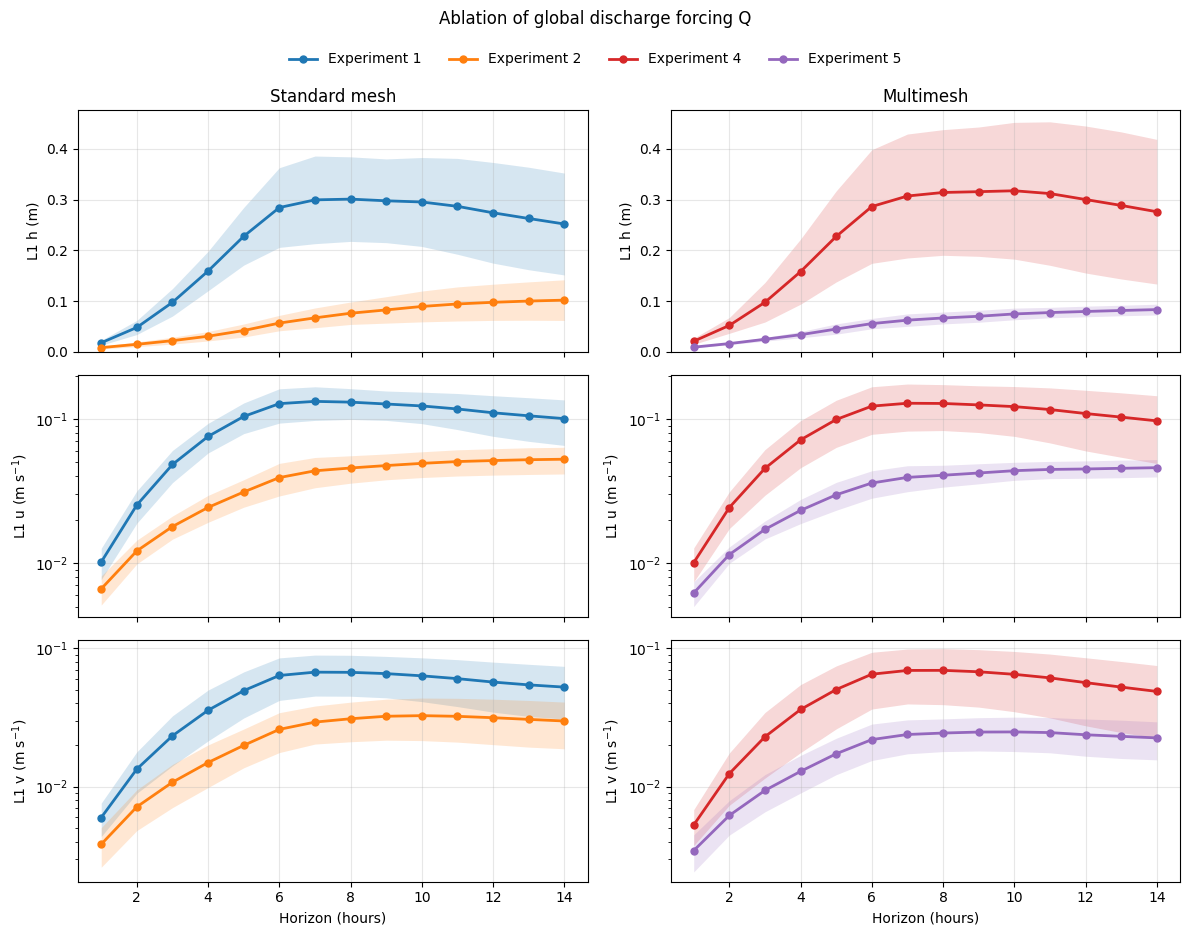

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# Palette globale: UNE couleur fixe par expérience
# ============================================================
EXPERIENCE_COLORS = {
    "Experiment 1": "#1f77b4",  # bleu
    "Experiment 2": "#ff7f0e",  # orange
    "Experiment 3": "#2ca02c",  # vert
    "Experiment 4": "#d62728",  # rouge
    "Experiment 5": "#9467bd",  # violet
    "Experiment 6": "#8c564b",  # brun
}

def _style_for_experience(label):
    return dict(
        color=EXPERIENCE_COLORS[label],
        marker="o",
        linewidth=2,
        markersize=5,
    )

def _build_legend_handles(labels):
    return [Line2D([0], [0], label=label, **_style_for_experience(label)) for label in labels]

def _extract_metric_mean_std(fixed_metrics, run_name, horizons_steps, metric_name, comp_idx=None, positive_only=False):
    if run_name not in fixed_metrics:
        available = ", ".join(sorted(fixed_metrics.keys()))
        raise KeyError(f"Run '{run_name}' absent de fixed_metrics. Disponibles: {available}")

    summary = fixed_metrics[run_name]["summary"]

    if comp_idx is None:
        mean_vals = np.array(
            [summary.get(step, {}).get(f"{metric_name}_mean", np.nan) for step in horizons_steps],
            dtype=float,
        )
        std_vals = np.array(
            [summary.get(step, {}).get(f"{metric_name}_std", np.nan) for step in horizons_steps],
            dtype=float,
        )
    else:
        mean_vals = np.array([
            summary.get(step, {}).get(f"{metric_name}_mean", [np.nan, np.nan, np.nan])[comp_idx]
            for step in horizons_steps
        ], dtype=float)
        std_vals = np.array([
            summary.get(step, {}).get(f"{metric_name}_std", [np.nan, np.nan, np.nan])[comp_idx]
            for step in horizons_steps
        ], dtype=float)

    if positive_only:
        mask = mean_vals <= 0.0
        mean_vals[mask] = np.nan
        std_vals[mask] = np.nan

    return mean_vals, std_vals


def plot_ablation_single_figure_l1_std(
    fixed_metrics,
    horizons_steps,
    run_groups,
    dt_seconds,
    title,
):
    """
    run_groups doit être de la forme :
    {
        "Standard mesh": {
            "Experiment 1": "Experiment 1@900",
            "Experiment 2": "Experiment 2@900",
        },
        "Multimesh": {
            "Experiment 4": "Experiment 4@900",
            "Experiment 5": "Experiment 5@900",
        },
    }
    """
    if not fixed_metrics:
        print("Pas de résultats")
        return

    hours = np.array([step * dt_seconds / 3600.0 for step in horizons_steps], dtype=float)

    columns = ["Standard mesh", "Multimesh"]
    rows = [
        (0, "h", 0, False, "L1 h (m)"),
        (1, "u", 1, True,  r"L1 u (m s$^{-1}$)"),
        (2, "v", 2, True,  r"L1 v (m s$^{-1}$)"),
    ]

    fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)

    legend_labels = []
    row_lowers = {0: [], 1: [], 2: []}
    row_uppers = {0: [], 1: [], 2: []}

    for col_idx, col_name in enumerate(columns):
        panel_runs = run_groups[col_name]

        for row_idx, comp_name, comp_idx, use_log, ylabel in rows:
            ax = axes[row_idx, col_idx]

            for exp_label, run_name in panel_runs.items():
                mean_vals, std_vals = _extract_metric_mean_std(
                    fixed_metrics,
                    run_name,
                    horizons_steps,
                    metric_name="l1",
                    comp_idx=comp_idx,
                    positive_only=use_log,
                )

                style = _style_for_experience(exp_label)
                ax.plot(hours, mean_vals, label=exp_label, **style)

                lower = mean_vals - std_vals
                upper = mean_vals + std_vals

                if use_log:
                    lower[lower <= 0.0] = np.nan

                ax.fill_between(
                    hours,
                    lower,
                    upper,
                    color=style["color"],
                    alpha=0.18,
                    linewidth=0,
                )

                valid_lower = lower[np.isfinite(lower)]
                valid_upper = upper[np.isfinite(upper)]

                if valid_lower.size > 0:
                    row_lowers[row_idx].append(np.nanmin(valid_lower))
                if valid_upper.size > 0:
                    row_uppers[row_idx].append(np.nanmax(valid_upper))

                if exp_label not in legend_labels:
                    legend_labels.append(exp_label)

            if row_idx == 0:
                ax.set_title(col_name)

            ax.set_ylabel(ylabel)
            ax.grid(True, alpha=0.3)

            if use_log:
                ax.set_yscale("log")

            if row_idx == 2:
                ax.set_xlabel("Horizon (hours)")

    # ------------------------------------------------------------
    # Synchronisation des axes Y deux à deux (gauche/droite)
    # ------------------------------------------------------------
    for row_idx, comp_name, comp_idx, use_log, ylabel in rows:
        if not row_lowers[row_idx] or not row_uppers[row_idx]:
            continue

        ymin = min(row_lowers[row_idx])
        ymax = max(row_uppers[row_idx])

        if use_log:
            ymin *= 0.85
            ymax *= 1.15
        else:
            ymin = min(0.0, ymin * 0.95)
            ymax *= 1.05

        axes[row_idx, 0].set_ylim(ymin, ymax)
        axes[row_idx, 1].set_ylim(ymin, ymax)

    fig.suptitle(title, y=0.93)
    fig.legend(
        handles=_build_legend_handles(legend_labels),
        loc="upper center",
        bbox_to_anchor=(0.5, 0.90),
        ncol=min(4, len(legend_labels)),
        frameon=False,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()


# ============================================================
# Ablation Q
# ============================================================
Q_ABLATION_SINGLE_FIGURE_RUNS = {
    "Standard mesh": {
        "Experiment 1": "Experiment 1@900",
        "Experiment 2": "Experiment 2@900",
    },
    "Multimesh": {
        "Experiment 4": "Experiment 4@900",
        "Experiment 5": "Experiment 5@900",
    },
}

plot_ablation_single_figure_l1_std(
    fixed_metrics,
    HORIZONS_STEPS,
    run_groups=Q_ABLATION_SINGLE_FIGURE_RUNS,
    dt_seconds=DT_SECONDS,
    title="Ablation of global discharge forcing Q",
)


# ============================================================
# Ablation PF
# ============================================================
PF_ABLATION_SINGLE_FIGURE_RUNS = {
    "Standard mesh": {
        "Experiment 2": "Experiment 2@900",
        "Experiment 3": "Experiment 3@900",
    },
    "Multimesh": {
        "Experiment 5": "Experiment 5@900",
        "Experiment 6": "Experiment 6@900",
    },
}



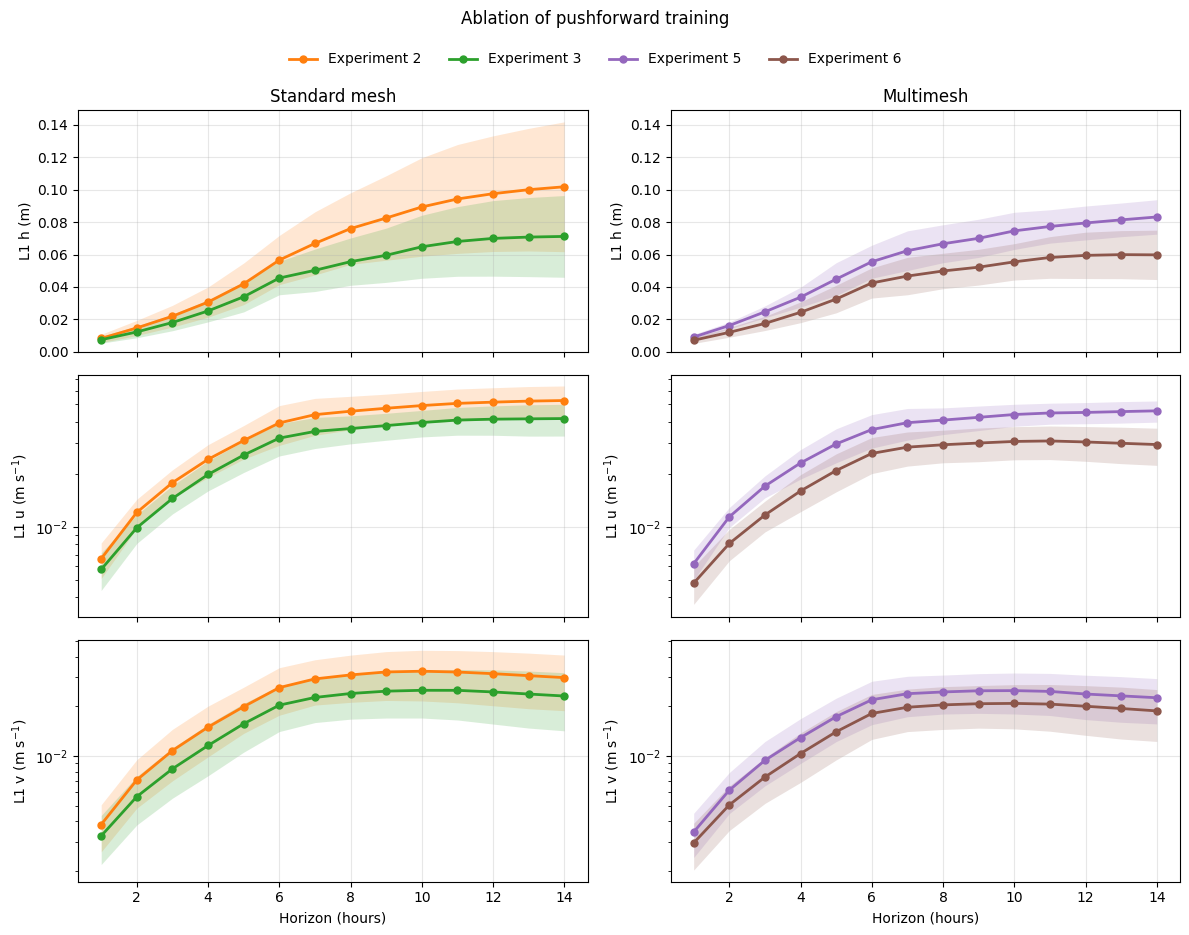

In [17]:
plot_ablation_single_figure_l1_std(
    fixed_metrics,
    HORIZONS_STEPS,
    run_groups=PF_ABLATION_SINGLE_FIGURE_RUNS,
    dt_seconds=DT_SECONDS,
    title="Ablation of pushforward training",
)

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def plot_multimesh_ablation_single_figure_l1_std(
    fixed_metrics,
    horizons_steps,
    pairs,
    dt_seconds,
    title="Ablation of multimesh",
):
    """
    pairs = [
        {
            "title": "Without Q / Without PF",
            "standard": "Experiment 1@900",
            "multimesh": "Experiment 4@900",
        },
        ...
    ]
    """
    if not fixed_metrics:
        print("Pas de résultats")
        return

    hours = np.array([step * dt_seconds / 3600.0 for step in horizons_steps], dtype=float)

    rows = [
        (0, 0, False, "L1 h (m)"),
        (1, 1, True,  r"L1 u (m s$^{-1}$)"),
        (2, 2, True,  r"L1 v (m s$^{-1}$)"),
    ]

    ncols = len(pairs)
    fig, axes = plt.subplots(3, ncols, figsize=(5 * ncols, 10), sharex=True)

    if ncols == 1:
        axes = np.array(axes).reshape(3, 1)

    legend_labels = []
    row_lowers = {0: [], 1: [], 2: []}
    row_uppers = {0: [], 1: [], 2: []}

    for col_idx, pair in enumerate(pairs):
        run_map = {
            pair["standard"].split("@")[0]: pair["standard"],
            pair["multimesh"].split("@")[0]: pair["multimesh"],
        }

        for row_idx, comp_idx, use_log, ylabel in rows:
            ax = axes[row_idx, col_idx]

            for exp_label, run_name in run_map.items():
                mean_vals, std_vals = _extract_metric_mean_std(
                    fixed_metrics,
                    run_name,
                    horizons_steps,
                    metric_name="l1",
                    comp_idx=comp_idx,
                    positive_only=use_log,
                )

                style = _style_for_experience(exp_label)
                ax.plot(hours, mean_vals, label=exp_label, **style)

                lower = mean_vals - std_vals
                upper = mean_vals + std_vals

                if use_log:
                    lower[lower <= 0.0] = np.nan

                ax.fill_between(
                    hours,
                    lower,
                    upper,
                    color=style["color"],
                    alpha=0.18,
                    linewidth=0,
                )

                valid_lower = lower[np.isfinite(lower)]
                valid_upper = upper[np.isfinite(upper)]

                if valid_lower.size > 0:
                    row_lowers[row_idx].append(np.nanmin(valid_lower))
                if valid_upper.size > 0:
                    row_uppers[row_idx].append(np.nanmax(valid_upper))

                if exp_label not in legend_labels:
                    legend_labels.append(exp_label)

            if row_idx == 0:
                ax.set_title(pair["title"])

            ax.set_ylabel(ylabel)
            ax.grid(True, alpha=0.3)

            if use_log:
                ax.set_yscale("log")

            if row_idx == 2:
                ax.set_xlabel("Horizon (hours)")

    for row_idx, comp_idx, use_log, ylabel in rows:
        if not row_lowers[row_idx] or not row_uppers[row_idx]:
            continue

        ymin = min(row_lowers[row_idx])
        ymax = max(row_uppers[row_idx])

        if use_log:
            ymin *= 0.85
            ymax *= 1.15
        else:
            ymin = min(0.0, ymin * 0.95)
            ymax *= 1.05

        for col_idx in range(ncols):
            axes[row_idx, col_idx].set_ylim(ymin, ymax)

    fig.suptitle(title, y=0.93)
    fig.legend(
        handles=_build_legend_handles(legend_labels),
        loc="upper center",
        bbox_to_anchor=(0.5, 0.90),
        ncol=min(6, len(legend_labels)),
        frameon=False,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()


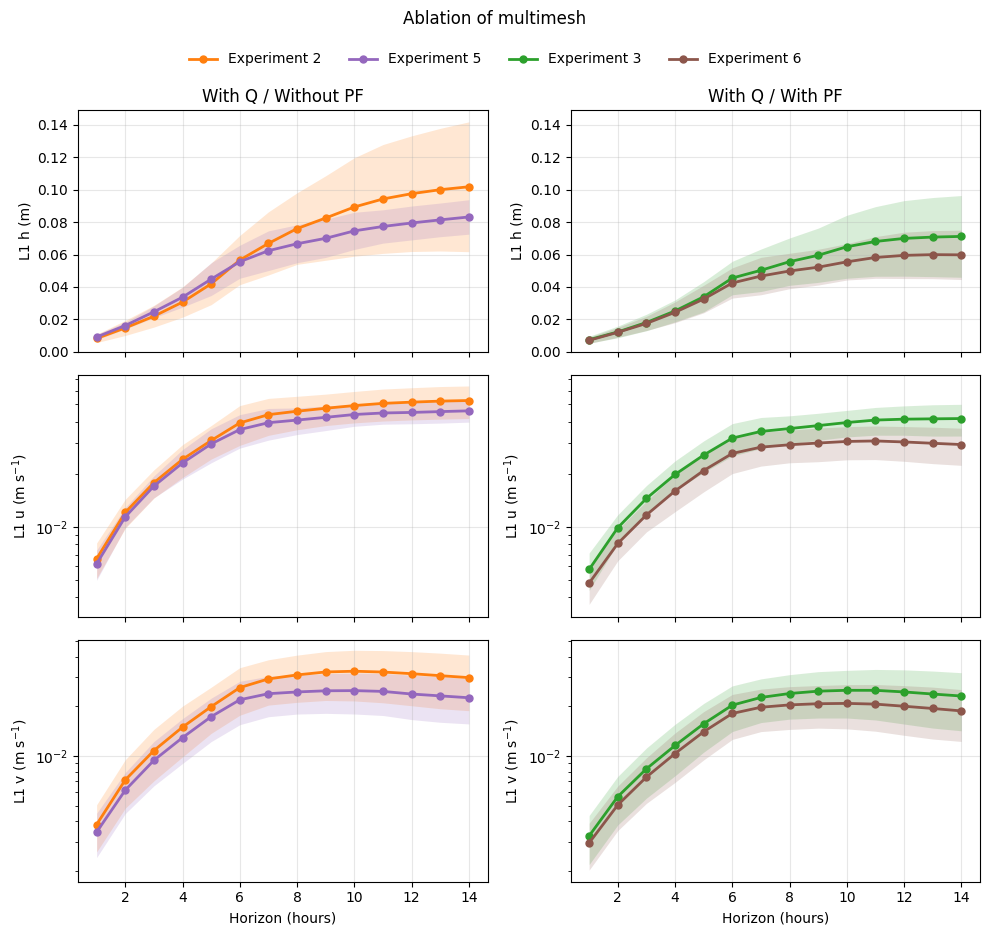

In [19]:
MULTIMESH_ABLATION_PAIRS = [
    {
        "title": "With Q / Without PF",
        "standard": "Experiment 2@900",
        "multimesh": "Experiment 5@900",
    },
    {
        "title": "With Q / With PF",
        "standard": "Experiment 3@900",
        "multimesh": "Experiment 6@900",
    },
]


plot_multimesh_ablation_single_figure_l1_std(
    fixed_metrics,
    HORIZONS_STEPS,
    pairs=MULTIMESH_ABLATION_PAIRS,
    dt_seconds=DT_SECONDS,
    title="Ablation of multimesh",
)

,Graph,Unique edges,Min [m],P05 [m],P25 [m],Median [m],P75 [m],P95 [m],Max [m],Max / Min
0,Reference Telemac mesh,1232165,0.75,2.70,4.89,6.97,21.06,52.59,82.97,110.59
1,Projected x8 mesh,48492,5.90,19.01,35.49,49.90,92.87,247.50,630.16,106.84
2,Projected x8 +multimesh,65279,5.90,21.50,39.49,64.15,135.10,353.38,2521.22,427.48


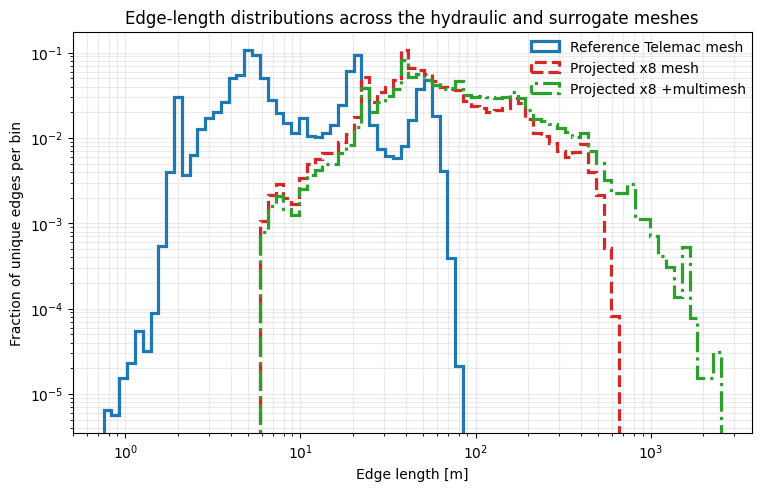

In [8]:
# Edge-length distributions for the paper
# This cell compares the reference Telemac mesh with the surrogate graphs used for learning.

import pandas as pd
from python.python_code.data_manip.extraction.telemac_file import TelemacFile

# Adjust this path to your original high-resolution Telemac mesh
HIGH_RES_MESH_PATH = "/work/m24046/m24046mrcr/results_data_30min/maillage_3.slf"

GRAPH_PATHS = {
    "Projected x8 mesh": DATA_DIRS["normal"],
    "Projected x8 +multimesh": DATA_DIRS["multimesh"],
}

SAVE_FIG = None  # e.g. "edge_length_distributions.png"


def unique_edge_lengths_from_telemac(mesh_path):
    mesh = TelemacFile(mesh_path)
    tri = mesh.tri.triangles

    # Unique undirected edges from triangles
    edges = np.vstack([
        np.sort(tri[:, [0, 1]], axis=1),
        np.sort(tri[:, [1, 2]], axis=1),
        np.sort(tri[:, [2, 0]], axis=1),
    ])
    edges = np.unique(edges, axis=0)

    x = np.asarray(mesh.tri.x)
    y = np.asarray(mesh.tri.y)
    dx = x[edges[:, 0]] - x[edges[:, 1]]
    dy = y[edges[:, 0]] - y[edges[:, 1]]
    return np.sqrt(dx**2 + dy**2)


def unique_edge_lengths_from_dgl(graph_path):
    graphs, _ = dgl.load_graphs(graph_path)
    g = graphs[0]

    src, dst = g.edges()
    src = src.cpu().numpy()
    dst = dst.cpu().numpy()

    # Remove duplicate directions and keep only unique undirected edges
    mask = src != dst
    undirected = np.sort(np.column_stack([src[mask], dst[mask]]), axis=1)
    _, first_idx = np.unique(undirected, axis=0, return_index=True)

    edge_lengths = g.edata["x"][:, 2].cpu().numpy()[mask]  # raw edge norm in meters
    return edge_lengths[np.sort(first_idx)]


def summarize_lengths(name, lengths):
    q05, q25, q50, q75, q95 = np.percentile(lengths, [5, 25, 50, 75, 95])
    return {
        "Graph": name,
        "Unique edges": len(lengths),
        "Min [m]": lengths.min(),
        "P05 [m]": q05,
        "P25 [m]": q25,
        "Median [m]": q50,
        "P75 [m]": q75,
        "P95 [m]": q95,
        "Max [m]": lengths.max(),
        "Max / Min": lengths.max() / lengths.min(),
    }


length_sets = {
    "Reference Telemac mesh": unique_edge_lengths_from_telemac(HIGH_RES_MESH_PATH),
    **{name: unique_edge_lengths_from_dgl(path) for name, path in GRAPH_PATHS.items()},
}

summary_df = pd.DataFrame(
    [summarize_lengths(name, lengths) for name, lengths in length_sets.items()]
)
display(summary_df.round(2))

all_lengths = np.concatenate(list(length_sets.values()))
bins = np.geomspace(all_lengths.min(), all_lengths.max(), 80)


plot_order = [
    "Reference Telemac mesh",
    "Projected x8 mesh",
    "Projected x8 +multimesh",
]

colors = {
    "Reference Telemac mesh": "#1f77b4",
    "Projected x8 mesh": "#d62728",
    "Projected x8 +multimesh": "#2ca02c",
}

linestyles = {
    "Reference Telemac mesh": "-",
    "Projected x8 mesh": "--",
    "Projected x8 +multimesh": "-.",
}

all_lengths = np.concatenate([length_sets[name] for name in plot_order])
bins = np.geomspace(all_lengths.min(), all_lengths.max(), 80)

fig, ax = plt.subplots(figsize=(7.5, 4.8), constrained_layout=True)

for name in plot_order:
    lengths = length_sets[name]
    weights = np.full(lengths.shape, 1.0 / len(lengths), dtype=float)

    ax.hist(
        lengths,
        bins=bins,
        weights=weights,
        histtype="step",
        linewidth=2.3,
        color=colors[name],
        linestyle=linestyles[name],
        label=name,
    )

ax.set_xscale("log")   # optional: remove if you prefer a linear x-axis
ax.set_yscale("log")
ax.set_xlabel("Edge length [m]")
ax.set_ylabel("Fraction of unique edges per bin")
ax.set_title("Edge-length distributions across the hydraulic and surrogate meshes")
ax.grid(True, which="both", alpha=0.25)
ax.legend(frameon=False, loc="upper right", bbox_to_anchor=(1.01, 1.01))

if SAVE_FIG is not None:
    fig.savefig(SAVE_FIG, dpi=300, bbox_inches="tight")

plt.show()

